In this notebook, we will be using qiskit to create simple circuits and visualise them. 

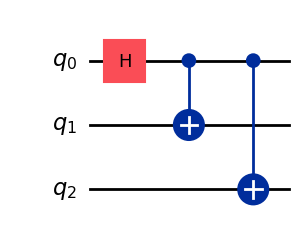

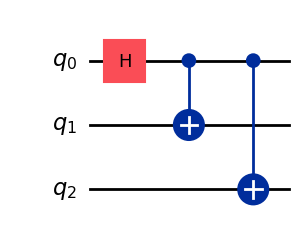

In [3]:
from qiskit import QuantumCircuit, transpiler
from qiskit.visualization import plot_circuit_layout, plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.visualization import circuit_drawer

qc = QuantumCircuit(3)

# GHZ state preparation
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
# Display the circuit
qc.draw("mpl")


The code above creates and displays a circuit diagram. The circuit uses the two qubits to create a maximally entangled state.

Next, we will look at a 3 qubit circuit, simulate it and plot the results in a histogram.


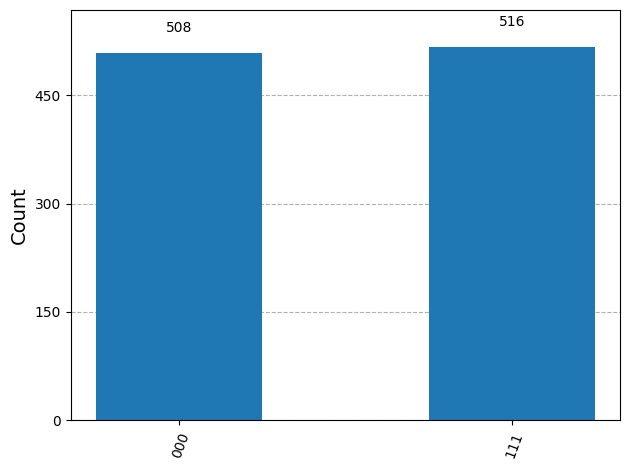

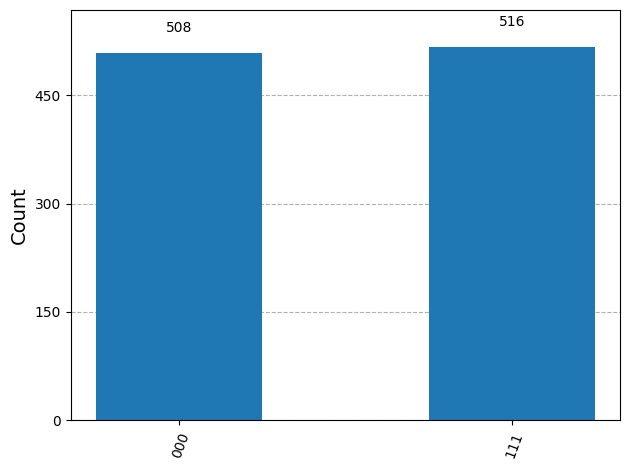

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1,2)
qc.measure_all()

backend = AerSimulator()
transpiled = transpile(qc, backend)
job = backend.run(transpiled, shots=1024)
result = job.result()
count = result.get_counts(qc)

plot_histogram(count)


The following circuit will be used to to simulate Deutch's algorithm for finding out weather a given one bit function is constant or balanced using only one query. On a classical computer this would take 2 queries to find out.

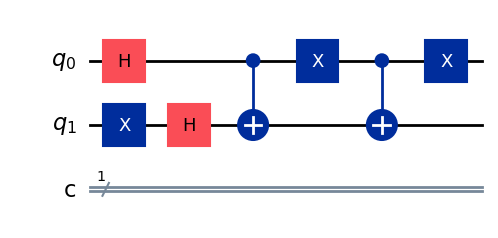

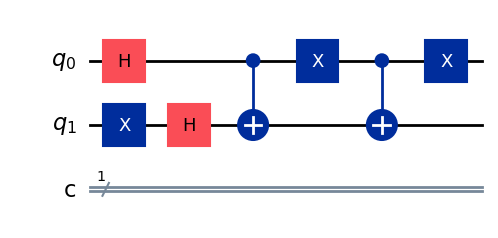

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

def f(x):
  if x == 0:
    return 1
  elif x == 1:
    return 0
qc = QuantumCircuit(2,1)
qc.h(0)
qc.x(1)
qc.h(1)
#Oracle call
if f(0) == 1:
  qc.cx(0,1)
  qc.x(0)
  qc.cx(0,1)
  qc.x(0)
elif f(1) == 1:
  qc.cx(0,1)



backend = AerSimulator()
transpiled = transpile(qc, backend)
qc.draw("mpl")
#plot_histogram(count)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[0, 1, 2]
swapping 0 1
(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=2>)
cz
     ┌───┐                   
q_0: ┤ H ├───────■──────X──■─
     ├───┤┌───┐┌─┴─┐    │  │ 
q_1: ┤ X ├┤ H ├┤ X ├─■──X──┼─
     └───┘└───┘└───┘ │     │ 
q_2: ────────────────■─────■─
                             
q_3: ────────────────────────
                             
q_4: ────────────────────────
                             


TypeError: 'int' object is not reversible

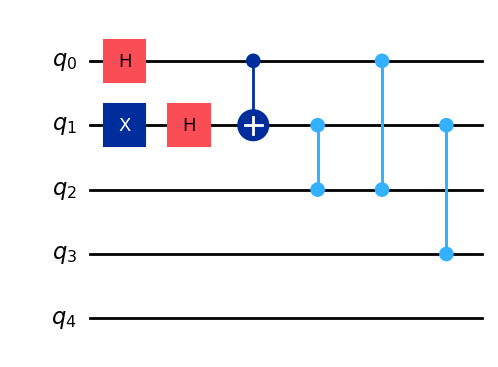

In [32]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

#Get jupyter to display more then one diagrams 
from IPython.display import display
# Make sure you're using the right magic
%matplotlib inline  
# or %matplotlib widget

qc1 = QuantumCircuit(5,0)
qc1.h(0)
qc1.x(1)
qc1.h(1)
qc1.cx(0,1)
qc1.cz(1,2)
qc1.cz(0,2)
qc1.cz(3,1)

qc1.draw("mpl")
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.hardware_aware import hardware_map


print(hardware_map.linkedHardware.make_compatible(qc1))

